# XGBoost para ShoW — versión corregida

Este notebook reorganiza el flujo de `XGboots_acotado.ipynb` para:

- mantener las ventanas T1 y T2 documentadas;
- conservar una única construcción del ShoW para entrenamiento y prueba;
- mantener el orden de los identificadores;
- evitar el ajuste preliminar duplicado;
- ejecutar el preprocesamiento numérico dentro del `Pipeline`;
- reservar el conjunto de prueba para la evaluación final;
- extraer la importancia desde el modelo seleccionado por `RandomizedSearchCV`.

**Ajuste respecto de la propuesta anterior:** se conserva la identificación tecnológica mediante coincidencias en `Category` o `Title`, porque esa es la regla implementada en el notebook y el documento principal no respalda de forma explícita cambiarla a `Title` únicamente.

La celda de auditoría de cohorte detendrá la ejecución si `train_ids.csv` o `test_ids.csv` contienen clientes que no aparecen en la cohorte construida en Python. Esto es intencional: evita continuar con una muestra reducida de forma silenciosa.


## Celda 1. Importaciones, rutas y versiones

In [6]:

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

import sklearn
import xgboost

warnings.filterwarnings("default")

RANDOM_STATE = 123

ROOT = Path.cwd()
DATA_DIR = (ROOT.parent / "pogit y replicacion de resultados/survey-data").resolve()

PURCHASES_PATH = DATA_DIR / "amazon-purchases.csv"
SURVEY_PATH = DATA_DIR / "survey2.csv"
TRAIN_IDS_PATH = ROOT / "train_ids.csv"
TEST_IDS_PATH = ROOT / "test_ids.csv"

required_paths = [
    PURCHASES_PATH,
    SURVEY_PATH,
    TRAIN_IDS_PATH,
    TEST_IDS_PATH,
]

missing_paths = [str(path) for path in required_paths if not path.exists()]

if missing_paths:
    raise FileNotFoundError(
        "No se encontraron los siguientes archivos:\n"
        + "\n".join(missing_paths)
    )

print("Directorio de trabajo:", ROOT)
print("Directorio de datos:", DATA_DIR)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)


Directorio de trabajo: c:\Users\workw\Documents\Proyecto aplicado\Github\Segmentacion-de-clientes-Samsung-SioW-SoW-y-Pow\XGBoots acotado entre 0,1
Directorio de datos: C:\Users\workw\Documents\Proyecto aplicado\Github\Segmentacion-de-clientes-Samsung-SioW-SoW-y-Pow\pogit y replicacion de resultados\survey-data
pandas: 2.3.3
numpy: 2.2.6
scikit-learn: 1.7.2
xgboost: 3.2.0


## Celda 2. Carga, limpieza, identificación tecnológica y ventanas

In [7]:
########################################################################################
# Carga y limpieza básica
########################################################################################

purchases_raw = pd.read_csv(PURCHASES_PATH)
survey = pd.read_csv(SURVEY_PATH)

print("Transacciones originales:", len(purchases_raw))


def normalize_response_id(series: pd.Series) -> pd.Series:
    normalized = (
        series
        .astype("string")
        .str.strip()
    )

    invalid_values = [
        "",
        "nan",
        "None",
        "<NA>",
    ]

    return normalized.mask(
        normalized.isin(invalid_values)
    )


########################################################################################
# Normalizar identificadores
########################################################################################

purchases_raw["Survey ResponseID"] = normalize_response_id(
    purchases_raw["Survey ResponseID"]
)

survey["Survey ResponseID"] = normalize_response_id(
    survey["Survey ResponseID"]
)

if purchases_raw["Survey ResponseID"].isna().any():
    raise ValueError(
        "Purchases contiene registros sin Survey ResponseID."
    )

if survey["Survey ResponseID"].isna().any():
    raise ValueError(
        "Survey contiene registros sin Survey ResponseID."
    )


########################################################################################
# Eliminar duplicados exactos
########################################################################################

n_duplicates = int(
    purchases_raw.duplicated().sum()
)

purchases = (
    purchases_raw
    .drop_duplicates()
    .copy()
)

print(
    "Duplicados exactos eliminados:",
    n_duplicates,
)

print(
    "Transacciones después de eliminar duplicados:",
    len(purchases),
)


########################################################################################
# Mantener una fila de encuesta por cliente
########################################################################################

n_duplicate_survey_ids = int(
    survey["Survey ResponseID"]
    .duplicated()
    .sum()
)

if n_duplicate_survey_ids > 0:
    print(
        "ID duplicados en Survey conservando la primera fila:",
        n_duplicate_survey_ids,
    )

survey = (
    survey
    .drop_duplicates(
        subset="Survey ResponseID",
        keep="first",
    )
    .copy()
)


########################################################################################
# Exclusión documentada de Q-life-changes
########################################################################################

if "Q-life-changes" in survey.columns:

    n_missing_life = int(
        survey["Q-life-changes"]
        .isna()
        .sum()
    )

    pct_missing_life = (
        n_missing_life
        / len(survey)
        * 100
    )

    print(
        "Q-life-changes:",
        n_missing_life,
        f"valores faltantes ({pct_missing_life:.2f} %)",
    )

    survey = survey.drop(
        columns=["Q-life-changes"]
    )


########################################################################################
# Preparar columnas base
########################################################################################

purchases["Order Date"] = pd.to_datetime(
    purchases["Order Date"],
    errors="coerce",
)

purchases["Purchase Price Per Unit"] = pd.to_numeric(
    purchases["Purchase Price Per Unit"],
    errors="coerce",
)

purchases["Quantity"] = pd.to_numeric(
    purchases["Quantity"],
    errors="coerce",
)

purchases["amount"] = (
    purchases["Purchase Price Per Unit"]
    * purchases["Quantity"]
)

# Se conserva la columna original para construir n_states
purchases["Shipping Address State_raw"] = (
    purchases["Shipping Address State"]
)


########################################################################################
# Textos normalizados
########################################################################################

title_lc = (
    purchases["Title"]
    .astype("string")
    .fillna("")
    .str.lower()
    .str.strip()
)

category_lc = (
    purchases["Category"]
    .astype("string")
    .fillna("")
    .str.lower()
    .str.strip()
)


########################################################################################
# Palabras utilizadas para identificar productos tecnológicos
# Misma estructura empleada en code2_survey_purchase_adaptado2.R
########################################################################################

electronics_keywords = [
    r"electronics?",
    r"computer",
    r"laptop",
    r"notebook",
    r"desktop",
    r"tablet",
    r"smartphone",
    r"\bphone\b",
    r"\btv\b",
    r"television",
    r"monitor",
    r"projector",
    r"printer",
    r"scanner",
    r"camera",
    r"webcam",
    r"speaker",
    r"audio",
    r"soundbar",
    r"headphones?",
    r"headset",
    r"earbuds?",
    r"microphone",
    r"charger",
    r"charging",
    r"battery",
    r"power(?: bank| supply)?",
    r"adapter",
    r"cable",
    r"dock(?:ing)?(?: station)?",
    r"\bmouse\b",
    r"keyboard",
    r"trackpad",
    r"controller",
    r"stylus",
    r"\bssd\b",
    r"(?:hard ?drive|hdd)",
    r"(?:flash ?drive|thumb ?drive)",
    r"\b(?:memory|ram)\b",
    r"\bgpu\b",
    r"graphics card",
    r"\busb\b",
    r"bluetooth",
    r"hdmi",
    r"\bethernet\b",
    r"\bwi[- ]?fi\b|wifi",
    r"smartwatch",
    r"wearable",
    r"router",
    r"modem",
    r"mesh(?: wifi)?",
    r"toner",
    r"\bink\b",
    r"(?:vr headset|virtual reality)",
]

electronics_pattern = "|".join(
    electronics_keywords
)


########################################################################################
# Clasificación de categorías amplias
# Equivalente a classify_category() del código R
########################################################################################

broad_category_conditions = [

    category_lc.str.contains(
        r"book|ebook|dvd|blu[-_ ]?ray|video_games?",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"apparel|clothing|hosiery|bra|coat|shoe|fashion",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"beauty|cosmetic|hair_|skin|lotion|fragrance",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"grocery|food|snack|beverage|coffee|tea|candy",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"kitchen|cook|bake|dinnerware|utensil|cookware",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"home_|furniture|decor|bedding|lamp|curtain|rug",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        electronics_pattern,
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"sport|fitness|exercise|camping|cycling|golf|ball",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"toy|game|lego|puzzle|doll|costume",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"pet_|animal",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"baby_",
        regex=True,
        na=False,
    ),

    category_lc.str.contains(
        r"auto|car|vehicle|engine|tire|battery",
        regex=True,
        na=False,
    ),
]

broad_category_choices = [
    "Media",
    "Apparel",
    "Beauty_PersonalCare",
    "Grocery",
    "Kitchen_Dining",
    "Home_Living",
    "Electronics",
    "Sports_Outdoors",
    "Toys_Games",
    "Pet_Supplies",
    "Baby",
    "Automotive",
]

purchases["broad_cat"] = np.select(
    broad_category_conditions,
    broad_category_choices,
    default="Other",
)


########################################################################################
# Identificación tecnológica inicial
# Título tecnológico O categoría amplia Electronics
########################################################################################

is_tech_by_title = title_lc.str.contains(
    electronics_pattern,
    regex=True,
    na=False,
)

purchases["is_tech"] = (
    is_tech_by_title
    | purchases["broad_cat"].eq("Electronics")
)


########################################################################################
# Identificación de marcas
# Conserva el orden del diccionario utilizado en R
########################################################################################

brand_patterns = [
    (r"\bsamsung\b", "Samsung"),
    (r"\bapple\b", "Apple"),
    (r"\bdell\b", "Dell"),
    (r"hewlett[ -]?packard|\bhp\b", "HP"),
    (r"\basus\b", "Asus"),
    (r"\bacer\b", "Acer"),
    (r"\blenovo\b", "Lenovo"),
    (r"\bhuawei\b", "Huawei"),
    (r"\bxiaomi\b", "Xiaomi"),
    (r"\bsony\b", "Sony"),
    (r"\blg\b", "LG"),
    (r"\bmotorola\b", "Motorola"),
    (r"\bnvidia\b", "Nvidia"),
    (r"\bamd\b", "AMD"),
    (r"\bintel\b", "Intel"),
    (r"\bcanon\b", "Canon"),
    (r"\bepson\b", "Epson"),
    (r"\blogitech\b", "Logitech"),
    (r"\banker\b", "Anker"),
    (r"\bseagate\b", "Seagate"),
    (r"\bsandisk\b", "Sandisk"),
    (r"\bkingston\b", "Kingston"),
    (r"tp[- ]?link", "TP-Link"),
    (r"\bnetgear\b", "Netgear"),
    (r"\bbose\b", "Bose"),
    (r"\bjbl\b", "JBL"),
]

purchases["tech_brand_raw"] = pd.NA

for pattern, brand in brand_patterns:

    brand_mask = (
        purchases["is_tech"]
        & purchases["tech_brand_raw"].isna()
        & title_lc.str.contains(
            pattern,
            regex=True,
            na=False,
        )
    )

    purchases.loc[
        brand_mask,
        "tech_brand_raw",
    ] = brand


purchases["tech_brand"] = pd.NA

tech_mask = purchases["is_tech"]

purchases.loc[
    tech_mask,
    "tech_brand",
] = (
    purchases.loc[
        tech_mask,
        "tech_brand_raw",
    ]
    .fillna("Generic")
)

purchases["is_samsung"] = (
    purchases["tech_brand"]
    .eq("Samsung")
    .fillna(False)
)


########################################################################################
# Primera base tecnológica
########################################################################################

purchases_tech = purchases.loc[
    purchases["is_tech"]
].copy()


########################################################################################
# Segundo filtro tecnológico utilizado en el código R
# Equivalente a purchases_tech2
########################################################################################

computers_pattern = (
    r"computer|desktop|laptop|notebook"
)

mobiles_pattern = (
    r"smartphone|\bphone\b|tablet"
)

input_pattern = (
    r"\bmouse\b|keyboard|trackpad|stylus|controller"
)

audio_video_pattern = (
    r"speaker|headphones?|headset|earbuds?|soundbar|"
    r"microphone|camera|webcam|projector|monitor|"
    r"\btv\b|television"
)

storage_pattern = (
    r"ssd|hard ?drive|hdd|flash ?drive|thumb ?drive|"
    r"memory|\bram\b|\bgpu\b|graphics card"
)

accessories_pattern = (
    r"charger|charging|battery|adapter|cable|"
    r"dock(?:ing)?(?: station)?|power bank|power supply|"
    r"toner|\bink\b"
)

connectivity_pattern = (
    r"\busb\b|bluetooth|hdmi|ethernet|"
    r"\bwi[- ]?fi\b|wifi|router|modem|mesh"
)

wearables_pattern = (
    r"smartwatch|wearable|vr headset|virtual reality"
)

tech_subcategory_pattern = "|".join(
    [
        computers_pattern,
        mobiles_pattern,
        input_pattern,
        audio_video_pattern,
        storage_pattern,
        accessories_pattern,
        connectivity_pattern,
        wearables_pattern,
    ]
)

purchases_tech2 = purchases_tech.loc[
    purchases_tech["Category"]
    .astype("string")
    .fillna("")
    .str.contains(
        tech_subcategory_pattern,
        case=False,
        regex=True,
        na=False,
    )
].copy()


########################################################################################
# Samsung dentro de la base tecnológica final
########################################################################################

purchases_samsung = purchases_tech2.loc[
    purchases_tech2["tech_brand"].eq("Samsung")
].copy()


########################################################################################
# Diagnóstico de faltantes sin sobrescribir columnas originales
########################################################################################

cols_con_nulos = [
    "Shipping Address State",
    "ASIN/ISBN (Product Code)",
    "Category",
]

for col in cols_con_nulos:

    purchases_samsung[
        f"{col}_missing"
    ] = (
        purchases_samsung[col]
        .isna()
        .astype(int)
    )


for col in [
    "Shipping Address State",
    "Category",
]:

    non_missing = (
        purchases_samsung[col]
        .dropna()
    )

    if non_missing.empty:
        raise ValueError(
            f"No es posible calcular la moda de {col}: "
            "todos los valores son nulos."
        )

    mode_value = (
        non_missing
        .mode()
        .iloc[0]
    )

    purchases_samsung[
        f"{col}_imputed"
    ] = (
        purchases_samsung[col]
        .fillna(mode_value)
    )


purchases_samsung["ASIN_ISBN_imputed"] = (
    purchases_samsung[
        "ASIN/ISBN (Product Code)"
    ]
    .fillna("No informado")
)


########################################################################################
# Ventanas temporales establecidas en la tesis
########################################################################################

T1_START = pd.Timestamp("2018-01-01")
T1_END = pd.Timestamp("2021-10-31")

T2_START = pd.Timestamp("2021-11-01")
T2_END = pd.Timestamp("2023-03-19")


########################################################################################
# Compras generales de T1 para n_states
########################################################################################

purchases_all_T1 = purchases.loc[
    purchases["Order Date"].between(
        T1_START,
        T1_END,
    )
    & purchases["amount"].gt(0)
].copy()


########################################################################################
# Compras Samsung tecnológicas de T1
########################################################################################

purchases_T1 = purchases_samsung.loc[
    purchases_samsung["Order Date"].between(
        T1_START,
        T1_END,
    )
    & purchases_samsung["amount"].gt(0)
    & purchases_samsung["Order Date"].notna()
].copy()


########################################################################################
# Compras tecnológicas totales de T2
########################################################################################

purchases_T2 = purchases_tech2.loc[
    purchases_tech2["Order Date"].between(
        T2_START,
        T2_END,
    )
    & purchases_tech2["amount"].gt(0)
    & purchases_tech2["Order Date"].notna()
].copy()


########################################################################################
# Resultados de control
########################################################################################

print(
    "Compras totales:",
    purchases.shape,
)

print(
    "Compras tecnológicas iniciales:",
    purchases_tech.shape,
)

print(
    "Compras tecnológicas después del segundo filtro:",
    purchases_tech2.shape,
)

print(
    "Compras tecnológicas Samsung:",
    purchases_samsung.shape,
)

print(
    "T1 Samsung:",
    purchases_T1.shape,
)

print(
    "T2 tecnología:",
    purchases_T2.shape,
)

print(
    "Clientes Samsung T1:",
    purchases_T1[
        "Survey ResponseID"
    ].nunique(),
)

print(
    "Transacciones tecnológicas finales con amount >= 5000:",
    int(
        purchases_tech2["amount"]
        .ge(5000)
        .sum()
    ),
)

Transacciones originales: 1850717
Duplicados exactos eliminados: 11624
Transacciones después de eliminar duplicados: 1839093
Q-life-changes: 3384 valores faltantes (67.32 %)
Compras totales: (1839093, 15)
Compras tecnológicas iniciales: (286510, 15)
Compras tecnológicas después del segundo filtro: (103030, 15)
Compras tecnológicas Samsung: (8946, 21)
T1 Samsung: (6194, 21)
T2 tecnología: (30097, 15)
Clientes Samsung T1: 2345
Transacciones tecnológicas finales con amount >= 5000: 3


## Celda 3. Variables RFM y últimos 12 meses

In [8]:

########################################################################################
# Variables RFM
########################################################################################

if "Order ID" in purchases_T1.columns:
    base = (
        purchases_T1
        .groupby(
            "Survey ResponseID",
            as_index=False,
        )
        .agg(
            recency_days=(
                "Order Date",
                lambda x: (T1_END - x.max()).days,
            ),
            frequency=("Order ID", "nunique"),
            monetary=("amount", "sum"),
        )
    )

    frequency_definition = "número de Order ID distintos"

else:
    base = (
        purchases_T1
        .groupby(
            "Survey ResponseID",
            as_index=False,
        )
        .agg(
            recency_days=(
                "Order Date",
                lambda x: (T1_END - x.max()).days,
            ),
            frequency=("Order Date", "count"),
            monetary=("amount", "sum"),
        )
    )

    frequency_definition = (
        "número de filas, porque Order ID no está disponible"
    )

print("Definición de frequency:", frequency_definition)
print("Clientes en base RFM:", len(base))

########################################################################################
# Variables de los últimos 12 meses de T1
########################################################################################

months_12m = pd.period_range(
    start=T1_END.to_period("M") - 11,
    end=T1_END.to_period("M"),
    freq="M",
)

purchases_12m = purchases_T1.loc[
    purchases_T1["Order Date"]
    .dt.to_period("M")
    .isin(months_12m)
].copy()

purchases_12m["month"] = (
    purchases_12m["Order Date"]
    .dt.to_period("M")
)

monthly_observed = (
    purchases_12m
    .groupby(
        ["Survey ResponseID", "month"],
        as_index=False,
    )
    .agg(
        dollar_m=("amount", "sum"),
        products_m=("Quantity", "sum"),
    )
)

monthly_grid = (
    pd.MultiIndex.from_product(
        [
            base["Survey ResponseID"].astype(str),
            months_12m,
        ],
        names=["Survey ResponseID", "month"],
    )
    .to_frame(index=False)
)

monthly = (
    monthly_grid
    .merge(
        monthly_observed,
        on=["Survey ResponseID", "month"],
        how="left",
        validate="one_to_one",
    )
)

monthly[["dollar_m", "products_m"]] = (
    monthly[["dollar_m", "products_m"]]
    .fillna(0)
)

feat_12m = (
    monthly
    .groupby(
        "Survey ResponseID",
        as_index=False,
    )
    .agg(
        dollar_avg_12m=("dollar_m", "mean"),
        dollar_top1_12m=("dollar_m", "max"),
    )
)

feat_12m["dollar_avg12_top1_ratio"] = np.where(
    feat_12m["dollar_top1_12m"].gt(0),
    (
        feat_12m["dollar_avg_12m"]
        / feat_12m["dollar_top1_12m"]
    ),
    0.0,
)

base = base.merge(
    feat_12m,
    on="Survey ResponseID",
    how="left",
    validate="one_to_one",
)

cols_12m = [
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio",
]

base[cols_12m] = base[cols_12m].fillna(0)

print("Base transaccional final:", base.shape)
display(base.head())


Definición de frequency: número de filas, porque Order ID no está disponible
Clientes en base RFM: 2345
Base transaccional final: (2345, 7)


,Survey ResponseID,recency_days,frequency,monetary,dollar_avg_12m,dollar_top1_12m,dollar_avg12_top1_ratio
0,R_01vNIayewjIIKMF,248,9,270.91,7.499167,89.99,0.083333
1,R_037XK72IZBJyF69,146,4,48.46,0.832500,9.99,0.083333
2,R_03aEbghUILs9NxD,23,1,10.99,0.915833,10.99,0.083333
3,R_06d9ULxrBmkwSTn,215,6,144.87,10.906667,119.97,0.090912
4,R_08uYA7fb4unHGkF,48,1,293.00,24.416667,293.00,0.083333


## Celda 4. Auditoría de la cohorte y del split

In [9]:

########################################################################################
# Cargar y auditar identificadores de entrenamiento y prueba
########################################################################################

def load_ids(path: Path) -> pd.Series:
    ids_df = pd.read_csv(path)

    if "response_id" not in ids_df.columns:
        raise ValueError(
            f"{path.name} no contiene la columna response_id."
        )

    ids = normalize_response_id(ids_df["response_id"])

    if ids.isna().any():
        raise ValueError(
            f"{path.name} contiene identificadores nulos o vacíos."
        )

    if ids.duplicated().any():
        duplicated = ids[ids.duplicated()].tolist()
        raise ValueError(
            f"{path.name} contiene ID duplicados: "
            f"{duplicated[:10]}"
        )

    return ids.reset_index(drop=True)


train_ids = load_ids(TRAIN_IDS_PATH)
test_ids = load_ids(TEST_IDS_PATH)

overlap = set(train_ids).intersection(set(test_ids))

if overlap:
    raise ValueError(
        "Existen clientes presentes simultáneamente en "
        f"entrenamiento y prueba: {list(overlap)[:10]}"
    )

base["Survey ResponseID"] = (
    base["Survey ResponseID"]
    .astype("string")
)

available_ids = set(base["Survey ResponseID"])

missing_train_ids = [
    response_id
    for response_id in train_ids
    if response_id not in available_ids
]

missing_test_ids = [
    response_id
    for response_id in test_ids
    if response_id not in available_ids
]

cohort_audit = pd.DataFrame(
    {
        "set": ["train", "test"],
        "ids_file": [len(train_ids), len(test_ids)],
        "ids_available_in_python": [
            len(train_ids) - len(missing_train_ids),
            len(test_ids) - len(missing_test_ids),
        ],
        "missing_ids": [
            len(missing_train_ids),
            len(missing_test_ids),
        ],
    }
)

display(cohort_audit)

if missing_train_ids or missing_test_ids:
    pd.DataFrame(
        {
            "response_id": (
                missing_train_ids + missing_test_ids
            ),
            "set": (
                ["train"] * len(missing_train_ids)
                + ["test"] * len(missing_test_ids)
            ),
        }
    ).to_csv(
        "cohort_missing_ids.csv",
        index=False,
    )

    raise ValueError(
        "La cohorte definida por train_ids.csv y test_ids.csv "
        "no coincide con la cohorte construida en Python. "
        "Revisa la identificación de productos tecnológicos, "
        "el tratamiento de atípicos y la generación de los ID. "
        "Se guardó cohort_missing_ids.csv."
    )

base_indexed = (
    base
    .drop_duplicates(
        subset="Survey ResponseID",
        keep="first",
    )
    .set_index("Survey ResponseID")
)

base_train = (
    base_indexed
    .loc[train_ids.tolist()]
    .reset_index()
)

base_test = (
    base_indexed
    .loc[test_ids.tolist()]
    .reset_index()
)

assert (
    base_train["Survey ResponseID"].tolist()
    == train_ids.tolist()
)

assert (
    base_test["Survey ResponseID"].tolist()
    == test_ids.tolist()
)

print("Base train:", base_train.shape)
print("Base test:", base_test.shape)


,set,ids_file,ids_available_in_python,missing_ids
0,train,1876,1876,0
1,test,469,469,0


Base train: (1876, 7)
Base test: (469, 7)


In [10]:
########################################################################################
# Revisar las transacciones de los clientes faltantes
########################################################################################

missing_ids = (
    missing_train_ids
    + missing_test_ids
)

columns_to_show = [
    "Survey ResponseID",
    "Order Date",
    "Title",
    "Category",
    "Purchase Price Per Unit",
    "Quantity",
    "amount",
    "is_tech",
    "is_samsung",
]

available_columns = [
    col
    for col in columns_to_show
    if col in purchases.columns
]

missing_transactions = (
    purchases.loc[
        purchases["Survey ResponseID"].isin(missing_ids),
        available_columns,
    ]
    .copy()
)

missing_transactions["in_T1"] = (
    missing_transactions["Order Date"]
    .between(T1_START, T1_END)
)

missing_transactions = (
    missing_transactions
    .sort_values(
        ["Survey ResponseID", "Order Date"]
    )
    .reset_index(drop=True)
)

display(missing_transactions)

missing_transactions.to_csv(
    "missing_ids_transactions.csv",
    index=False,
)

,Survey ResponseID,Order Date,Title,Category,Purchase Price Per Unit,Quantity,amount,is_tech,is_samsung,in_T1


In [11]:
id_cliente = "R_2wsEjZPqLx1a09x"

compras_cliente = purchases.loc[
    purchases["Survey ResponseID"].eq(id_cliente)
].copy()

print(
    "Total de registros:",
    len(compras_cliente)
)

print(
    "Registros identificados como Samsung:",
    int(compras_cliente["is_samsung"].sum())
)

print(
    "Registros tecnológicos Samsung en T1:",
    int(
        (
            compras_cliente["is_samsung"]
            & compras_cliente["is_tech"]
            & compras_cliente["Order Date"].between(
                T1_START,
                T1_END
            )
        ).sum()
    )
)

Total de registros: 348
Registros identificados como Samsung: 3
Registros tecnológicos Samsung en T1: 2


In [12]:
id_cliente = "R_2wsEjZPqLx1a09x"

compras_cliente = purchases.loc[
    purchases["Survey ResponseID"].eq(id_cliente)
].copy()

compras_cliente["in_T1"] = (
    compras_cliente["Order Date"]
    .between(T1_START, T1_END)
)

columnas_revision = [
    "Survey ResponseID",
    "Order Date",
    "Title",
    "Category",
    "Purchase Price Per Unit",
    "Quantity",
    "amount",
    "is_tech",
    "is_samsung",
    "in_T1",
]

compras_samsung_cliente = (
    compras_cliente.loc[
        compras_cliente["is_samsung"],
        columnas_revision,
    ]
    .sort_values("Order Date")
    .reset_index(drop=True)
)

display(compras_samsung_cliente)

,Survey ResponseID,Order Date,Title,Category,Purchase Price Per Unit,Quantity,amount,is_tech,is_samsung,in_T1
0,R_2wsEjZPqLx1a09x,2020-05-20,Samsung Galaxy Tab A 8.4 Case for Kids| SIBEIT...,PORTABLE_ELECTRONIC_DEVICE_COVER,19.99,1.0,19.99,True,True,True
1,R_2wsEjZPqLx1a09x,2020-05-20,Glass Screen Cover Replacement for Samsung Gal...,COMPUTER_ADD_ON,17.99,1.0,17.99,True,True,True
2,R_2wsEjZPqLx1a09x,2022-01-20,LTROP Samsung Galaxy Tab A7 Lite Case 8.7 Inch...,PORTABLE_ELECTRONIC_DEVICE_COVER,15.98,1.0,15.98,True,True,False


In [13]:
compras_samsung_cliente["Title"].value_counts(dropna=False)

Title
Samsung Galaxy Tab A 8.4 Case for Kids| SIBEITU SM-T307/SM-T307U Case with Screen Protector Pencil Holder | Full-Body Rugged Heavy Duty Cover w/Stand Shoulder Strap for Kids| SkyBlue              1
Glass Screen Cover Replacement for Samsung Galaxy Tab A 8.4 2020 T307 Black                                                                                                                         1
LTROP Samsung Galaxy Tab A7 Lite Case 8.7 Inch 2021,Galaxy Tab A7 Lite Case with Shoulder Strap,Shockproof Handle Stand Kids Case for Samsung Galaxy Tab A7 Lite 8.7" (SM-T220/T225/T227), Black    1
Name: count, dtype: int64

In [14]:
resumen_cliente = pd.DataFrame(
    {
        "criterio": [
            "Registros totales",
            "Registros Samsung",
            "Registros tecnológicos",
            "Registros dentro de T1",
            "Samsung dentro de T1",
            "Samsung tecnológico",
            "Samsung tecnológico dentro de T1",
        ],
        "cantidad": [
            len(compras_cliente),
            int(compras_cliente["is_samsung"].sum()),
            int(compras_cliente["is_tech"].sum()),
            int(compras_cliente["in_T1"].sum()),
            int(
                (
                    compras_cliente["is_samsung"]
                    & compras_cliente["in_T1"]
                ).sum()
            ),
            int(
                (
                    compras_cliente["is_samsung"]
                    & compras_cliente["is_tech"]
                ).sum()
            ),
            int(
                (
                    compras_cliente["is_samsung"]
                    & compras_cliente["is_tech"]
                    & compras_cliente["in_T1"]
                ).sum()
            ),
        ],
    }
)

display(resumen_cliente)

,criterio,cantidad
0,Registros totales,348
1,Registros Samsung,3
2,Registros tecnológicos,7
3,Registros dentro de T1,103
4,Samsung dentro de T1,2
5,Samsung tecnológico,3
6,Samsung tecnológico dentro de T1,2


## Celda 5. Encuesta, raza y n_states

In [15]:

########################################################################################
# Variables de encuesta, raza y n_states
########################################################################################

ordinal_cols = [
    "Q-amazon-use-how-oft",
    "Q-demos-age",
    "Q-demos-education",
    "Q-demos-income",
    "Q-amazon-use-howmany",
    "Q-amazon-use-hh-size",
]

nominal_cols = [
    "Q-demos-hispanic",
    "Q-demos-gender",
    "Q-sexual-orientation",
    "Q-substance-use-cigarettes",
    "Q-substance-use-marijuana",
    "Q-substance-use-alcohol",
    "Q-personal-diabetes",
    "Q-personal-wheelchair",
]

ordinal_cols = [
    col for col in ordinal_cols
    if col in survey.columns
]

nominal_cols = [
    col for col in nominal_cols
    if col in survey.columns
]

########################################################################################
# Raza multirrespuesta
########################################################################################

race_categories = [
    "White or Caucasian",
    "Asian",
    "Black or African American",
    "Other",
    "American Indian/Native American or Alaska Native",
    "Native Hawaiian or Other Pacific Islander",
]

def split_races(value):
    if pd.isna(value):
        return []

    value = str(value).strip()

    if value == "" or value.lower() in {
        "nan",
        "none",
        "unknown",
    }:
        return []

    # La barra "/" forma parte de nombres válidos de categorías.
    value = re.sub(r"\s*/\s*", "/", value)

    # Separar únicamente respuestas múltiples.
    parts = re.split(r";|,|\|", value)

    parts = [
        part.strip()
        for part in parts
        if part.strip()
    ]

    return list(dict.fromkeys(parts))


race_cols = []

for race in race_categories:
    col_name = (
        "race_"
        + race.lower()
              .replace(" ", "_")
              .replace("/", "_")
              .replace("-", "_")
    )

    survey[col_name] = survey["Q-demos-race"].apply(
        lambda value, race=race: int(
            race in split_races(value)
        )
    )

    race_cols.append(col_name)

########################################################################################
# Variables de encuesta a nivel de cliente
########################################################################################

survey_feature_cols = (
    ["Survey ResponseID"]
    + ordinal_cols
    + nominal_cols
    + race_cols
)

survey_features = (
    survey[survey_feature_cols]
    .drop_duplicates(
        subset="Survey ResponseID",
        keep="first",
    )
    .copy()
)

########################################################################################
# n_states usando todas las compras de T1
########################################################################################

def build_n_states(
    ids: pd.Series,
    purchases_t1: pd.DataFrame,
) -> pd.DataFrame:

    ids = ids.astype("string")

    purchases_subset = purchases_t1.loc[
        purchases_t1["Survey ResponseID"].isin(ids)
    ].copy()

    purchases_subset["shipping_state_clean"] = (
        purchases_subset["Shipping Address State_raw"]
        .astype("string")
        .str.strip()
        .str.upper()
        .replace(
            ["", "NAN", "NONE", "<NA>"],
            pd.NA,
        )
        .fillna("DIGITAL/LOCKER")
    )

    state_summary = (
        purchases_subset
        .assign(
            state_for_count=lambda data: (
                data["shipping_state_clean"]
                .where(
                    data["shipping_state_clean"]
                    != "DIGITAL/LOCKER",
                    pd.NA,
                )
            )
        )
        .groupby(
            "Survey ResponseID",
            as_index=False,
        )
        .agg(
            n_states=(
                "state_for_count",
                "nunique",
            )
        )
    )

    result = (
        pd.DataFrame(
            {
                "Survey ResponseID": ids.tolist()
            }
        )
        .merge(
            state_summary,
            on="Survey ResponseID",
            how="left",
            validate="one_to_one",
            sort=False,
        )
    )

    result["n_states"] = (
        result["n_states"]
        .fillna(0)
        .astype(int)
    )

    return result


state_summ_train = build_n_states(
    train_ids,
    purchases_all_T1,
)

state_summ_test = build_n_states(
    test_ids,
    purchases_all_T1,
)

########################################################################################
# Integrar variables por cliente
########################################################################################

def build_client_features(
    base_subset: pd.DataFrame,
    ids: pd.Series,
    state_summary: pd.DataFrame,
) -> pd.DataFrame:

    result = (
        base_subset
        .merge(
            survey_features,
            on="Survey ResponseID",
            how="left",
            validate="one_to_one",
            sort=False,
        )
        .merge(
            state_summary,
            on="Survey ResponseID",
            how="left",
            validate="one_to_one",
            sort=False,
        )
    )

    result[race_cols] = (
        result[race_cols]
        .fillna(0)
        .astype(int)
    )

    result["n_states"] = (
        result["n_states"]
        .fillna(0)
        .astype(int)
    )

    result = (
        result
        .set_index("Survey ResponseID")
        .loc[ids.tolist()]
        .reset_index()
    )

    if result["Survey ResponseID"].tolist() != ids.tolist():
        raise ValueError(
            "El orden de los clientes cambió durante la integración."
        )

    return result


base_clientes_train = build_client_features(
    base_train,
    train_ids,
    state_summ_train,
)

base_clientes_test = build_client_features(
    base_test,
    test_ids,
    state_summ_test,
)

print("Clientes train con variables:", base_clientes_train.shape)
print("Clientes test con variables:", base_clientes_test.shape)


Clientes train con variables: (1876, 28)
Clientes test con variables: (469, 28)


## Celda 6. Codificación ordinal y nominal

In [16]:

########################################################################################
# Codificación ordinal y nominal
########################################################################################

ordinal_mappings = {
    "Q-demos-education": {
        "Some high school or less": 0,
        "High school diploma or GED": 1,
        "Bachelor's degree": 2,
        "Graduate or professional degree (MA, MS, MBA, PhD, JD, MD, DDS, etc)": 3,
        "Prefer not to say": np.nan,
    },
    "Q-demos-income": {
        "Less than $25,000": 0,
        "$25,000 - $49,999": 1,
        "$50,000 - $74,999": 2,
        "$75,000 - $99,999": 3,
        "$100,000 - $149,999": 4,
        "$150,000 or more": 5,
        "Prefer not to say": np.nan,
    },
    "Q-amazon-use-how-oft": {
        "Less than 5 times per month": 0,
        "5 - 10 times per month": 1,
        "More than 10 times per month": 2,
    },
    "Q-amazon-use-howmany": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3,
    },
    "Q-demos-age": {
        "18 - 24 years": 0,
        "25 - 34 years": 1,
        "35 - 44 years": 2,
        "45 - 54 years": 3,
        "55 - 64 years": 4,
        "65 and older": 5,
    },
    "Q-amazon-use-hh-size": {
        "1 (just me!)": 0,
        "2": 1,
        "3": 2,
        "4+": 3,
    },
}

reference_levels = {
    "Q-demos-hispanic": "No",
    "Q-demos-gender": "Male",
    "Q-sexual-orientation": "heterosexual (straight)",
    "Q-substance-use-cigarettes": "No",
    "Q-substance-use-marijuana": "No",
    "Q-substance-use-alcohol": "No",
    "Q-personal-diabetes": "No",
    "Q-personal-wheelchair": "No",
}

def apply_ordinal_mappings(
    data: pd.DataFrame,
) -> pd.DataFrame:

    output = data.copy()

    for col, mapping in ordinal_mappings.items():
        if col not in output.columns:
            continue

        observed = set(
            output[col]
            .dropna()
            .astype(str)
            .unique()
        )

        allowed = set(mapping.keys())
        unknown = sorted(observed - allowed)

        if unknown:
            raise ValueError(
                f"Categorías ordinales no contempladas en {col}: "
                f"{unknown}"
            )

        output[col] = output[col].map(mapping)

    return output


def fit_nominal_encoding(
    data: pd.DataFrame,
):
    output = data.copy()
    dummy_parts = []
    category_schema = {}

    for col in nominal_cols:
        if col not in output.columns:
            continue

        values = (
            output[col]
            .astype("string")
            .fillna("Missing")
        )

        reference = reference_levels[col]
        observed = list(pd.unique(values))

        if reference not in observed:
            raise ValueError(
                f"La categoría de referencia '{reference}' "
                f"no aparece en entrenamiento para {col}. "
                f"Categorías observadas: {observed}"
            )

        categories = (
            [reference]
            + [
                category
                for category in observed
                if category != reference
            ]
        )

        category_schema[col] = categories

        categorical_values = pd.Categorical(
            values,
            categories=categories,
        )

        dummies = pd.get_dummies(
            categorical_values,
            prefix=col,
            drop_first=True,
            dtype=int,
        )

        dummy_parts.append(dummies)

    if dummy_parts:
        nominal_dummies = pd.concat(
            dummy_parts,
            axis=1,
        )
    else:
        nominal_dummies = pd.DataFrame(
            index=output.index
        )

    output = output.drop(
        columns=[
            col
            for col in nominal_cols
            if col in output.columns
        ]
    )

    output = pd.concat(
        [
            output.reset_index(drop=True),
            nominal_dummies.reset_index(drop=True),
        ],
        axis=1,
    )

    dummy_columns = nominal_dummies.columns.tolist()

    return output, category_schema, dummy_columns


def transform_nominal_encoding(
    data: pd.DataFrame,
    category_schema: dict,
    dummy_columns: list[str],
) -> pd.DataFrame:

    output = data.copy()
    dummy_parts = []

    for col in nominal_cols:
        if col not in output.columns:
            continue

        values = (
            output[col]
            .astype("string")
            .fillna("Missing")
        )

        categories = category_schema[col]

        unknown = sorted(
            set(values.unique())
            - set(categories)
        )

        if unknown:
            raise ValueError(
                f"Categorías no observadas en entrenamiento "
                f"para {col}: {unknown}"
            )

        categorical_values = pd.Categorical(
            values,
            categories=categories,
        )

        dummies = pd.get_dummies(
            categorical_values,
            prefix=col,
            drop_first=True,
            dtype=int,
        )

        dummy_parts.append(dummies)

    if dummy_parts:
        nominal_dummies = (
            pd.concat(
                dummy_parts,
                axis=1,
            )
            .reindex(
                columns=dummy_columns,
                fill_value=0,
            )
        )
    else:
        nominal_dummies = pd.DataFrame(
            index=output.index,
            columns=dummy_columns,
        ).fillna(0)

    output = output.drop(
        columns=[
            col
            for col in nominal_cols
            if col in output.columns
        ]
    )

    output = pd.concat(
        [
            output.reset_index(drop=True),
            nominal_dummies.reset_index(drop=True),
        ],
        axis=1,
    )

    return output


df_train_encoded = apply_ordinal_mappings(
    base_clientes_train
)

df_test_encoded = apply_ordinal_mappings(
    base_clientes_test
)

(
    df_model_train,
    nominal_schema,
    nominal_dummy_columns,
) = fit_nominal_encoding(
    df_train_encoded
)

df_model_test = transform_nominal_encoding(
    df_test_encoded,
    nominal_schema,
    nominal_dummy_columns,
)

cols_12m = [
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio",
]

df_model_train[cols_12m] = (
    df_model_train[cols_12m]
    .fillna(0)
)

df_model_test[cols_12m] = (
    df_model_test[cols_12m]
    .fillna(0)
)

print("Columnas train:", df_model_train.shape[1])
print("Columnas test:", df_model_test.shape[1])


Columnas train: 39
Columnas test: 39


## Celda 7. ShoW empírico y alineación de train/test

In [17]:

########################################################################################
# Construcción única del ShoW empírico para train y test
########################################################################################

def build_empirical_sow(
    ids: pd.Series,
    purchases_t2: pd.DataFrame,
) -> pd.DataFrame:

    ids = ids.astype("string")

    transactions = purchases_t2.loc[
        purchases_t2["Survey ResponseID"].isin(ids)
    ].copy()

    transactions["amount_samsung"] = np.where(
        transactions["is_samsung"],
        transactions["amount"],
        0.0,
    )

    summary = (
        transactions
        .groupby(
            "Survey ResponseID",
            as_index=False,
        )
        .agg(
            amount_samsung=("amount_samsung", "sum"),
            amount_total=("amount", "sum"),
        )
    )

    result = (
        pd.DataFrame(
            {
                "Survey ResponseID": ids.tolist()
            }
        )
        .merge(
            summary,
            on="Survey ResponseID",
            how="left",
            validate="one_to_one",
            sort=False,
        )
    )

    result[
        ["amount_samsung", "amount_total"]
    ] = (
        result[
            ["amount_samsung", "amount_total"]
        ]
        .fillna(0)
    )

    result["sow_empirical"] = np.where(
        result["amount_total"].gt(0),
        (
            result["amount_samsung"]
            / result["amount_total"]
        ),
        0.0,
    )

    if not result["sow_empirical"].between(0, 1).all():
        raise ValueError(
            "Se encontraron valores de ShoW fuera de [0, 1]."
        )

    return result


sow_train = build_empirical_sow(
    train_ids,
    purchases_T2,
)

sow_test = build_empirical_sow(
    test_ids,
    purchases_T2,
)

########################################################################################
# Alinear identificadores, variables y respuesta
########################################################################################

train_model = df_model_train.merge(
    sow_train[
        ["Survey ResponseID", "sow_empirical"]
    ],
    on="Survey ResponseID",
    how="inner",
    validate="one_to_one",
    sort=False,
)

test_model = df_model_test.merge(
    sow_test[
        ["Survey ResponseID", "sow_empirical"]
    ],
    on="Survey ResponseID",
    how="inner",
    validate="one_to_one",
    sort=False,
)

train_model = (
    train_model
    .set_index("Survey ResponseID")
    .loc[train_ids.tolist()]
    .reset_index()
)

test_model = (
    test_model
    .set_index("Survey ResponseID")
    .loc[test_ids.tolist()]
    .reset_index()
)

assert (
    train_model["Survey ResponseID"].tolist()
    == train_ids.tolist()
)

assert (
    test_model["Survey ResponseID"].tolist()
    == test_ids.tolist()
)

X_train = train_model.drop(
    columns=[
        "Survey ResponseID",
        "sow_empirical",
    ]
)

y_train = (
    train_model["sow_empirical"]
    .astype(float)
)

X_test_f = test_model.drop(
    columns=[
        "Survey ResponseID",
        "sow_empirical",
    ]
)

# La codificación de test debe reproducir exactamente
# las columnas aprendidas con entrenamiento.
extra_test_cols = sorted(
    set(X_test_f.columns)
    - set(X_train.columns)
)

missing_test_cols = sorted(
    set(X_train.columns)
    - set(X_test_f.columns)
)

if extra_test_cols or missing_test_cols:
    print("Columnas extra en test:", extra_test_cols)
    print("Columnas faltantes en test:", missing_test_cols)

X_test_f = X_test_f.reindex(
    columns=X_train.columns,
    fill_value=0,
)

y_test = (
    test_model["sow_empirical"]
    .astype(float)
)

test_response_ids = (
    test_model["Survey ResponseID"]
    .astype(str)
)

assert len(X_train) == len(y_train) == len(train_ids)
assert len(X_test_f) == len(y_test) == len(test_ids)

print("X_train:", X_train.shape)
print("X_test:", X_test_f.shape)
print("ShoW train entre 0 y 1:", y_train.between(0, 1).all())
print("ShoW test entre 0 y 1:", y_test.between(0, 1).all())


X_train: (1876, 38)
X_test: (469, 38)
ShoW train entre 0 y 1: True
ShoW test entre 0 y 1: True


## Celda 8. Transformador de winsorización

In [18]:

########################################################################################
# Winsorización de Tukey estimada únicamente con entrenamiento
########################################################################################

class TukeyWinsorizer(BaseEstimator, TransformerMixin):
    def __init__(self, k=3.0):
        self.k = k
        self.caps_ = None

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()

        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1

        self.caps_ = q3 + self.k * iqr

        return self

    def transform(self, X):
        if self.caps_ is None:
            raise RuntimeError(
                "TukeyWinsorizer debe ajustarse antes de transformar."
            )

        X_df = pd.DataFrame(X).copy()

        return X_df.clip(
            upper=self.caps_,
            axis=1,
        )


## Celda 9. Pipeline de preprocesamiento

In [19]:

########################################################################################
# Pipeline de preprocesamiento
########################################################################################

numeric_cols = [
    "recency_days",
    "frequency",
    "monetary",
    "dollar_avg_12m",
    "dollar_top1_12m",
    "dollar_avg12_top1_ratio",
    "n_states",
]

impute_cols = [
    "Q-demos-education",
    "Q-demos-income",
]

required_model_cols = numeric_cols + impute_cols

missing_model_cols = [
    col for col in required_model_cols
    if col not in X_train.columns
]

if missing_model_cols:
    raise ValueError(
        "Faltan variables requeridas en X_train: "
        f"{missing_model_cols}"
    )

cat_cols = [
    col for col in X_train.columns
    if col not in numeric_cols + impute_cols
]

numeric_pipeline = Pipeline(
    steps=[
        (
            "winsor",
            TukeyWinsorizer(k=3.0),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
    ]
)

imputation_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median"),
        ),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_cols,
        ),
        (
            "impute",
            imputation_pipeline,
            impute_cols,
        ),
        (
            "cat",
            "passthrough",
            cat_cols,
        ),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Variables numéricas:", len(numeric_cols))
print("Variables con imputación por mediana:", len(impute_cols))
print("Variables categóricas/binarias de paso directo:", len(cat_cols))


Variables numéricas: 7
Variables con imputación por mediana: 2
Variables categóricas/binarias de paso directo: 29


## Celda 10. Validación cruzada estratificada

In [20]:

########################################################################################
# Validación cruzada estratificada por intervalos de ShoW
########################################################################################

y_train = y_train.astype(float)

if not y_train.between(0, 1).all():
    raise ValueError(
        "y_train debe estar en [0, 1] para objective='reg:logistic'."
    )

y_bins = pd.cut(
    y_train,
    bins=[-0.001, 0, 0.05, 1.0],
    labels=[
        "0",
        "0-0.05",
        "0.05-1.00",
    ],
    include_lowest=True,
)

if y_bins.isna().any():
    raise ValueError(
        "No fue posible asignar todos los valores de ShoW "
        "a los intervalos de estratificación."
    )

bin_counts = (
    y_bins
    .value_counts()
    .sort_index()
)

display(
    bin_counts.rename("n").to_frame()
)

N_SPLITS = 5

if bin_counts.min() < N_SPLITS:
    raise ValueError(
        "Algún intervalo tiene menos observaciones "
        "que el número de particiones."
    )

cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_splits = list(
    cv.split(
        X_train,
        y_bins,
    )
)

for fold, (_, val_idx) in enumerate(
    cv_splits,
    start=1,
):
    print(f"\nFold {fold}")
    print(
        y_bins.iloc[val_idx]
        .value_counts()
        .sort_index()
    )


,n
sow_empirical,
0,1027
0-0.05,274
0.05-1.00,575



Fold 1
sow_empirical
0            206
0-0.05        55
0.05-1.00    115
Name: count, dtype: int64

Fold 2
sow_empirical
0            206
0-0.05        54
0.05-1.00    115
Name: count, dtype: int64

Fold 3
sow_empirical
0            205
0-0.05        55
0.05-1.00    115
Name: count, dtype: int64

Fold 4
sow_empirical
0            205
0-0.05        55
0.05-1.00    115
Name: count, dtype: int64

Fold 5
sow_empirical
0            205
0-0.05        55
0.05-1.00    115
Name: count, dtype: int64


## Celda 11. Optimización de hiperparámetros

In [21]:
########################################################################################
# Modelo XGBoost y optimización de hiperparámetros
########################################################################################

import gc

########################################################################################
# Modelo XGBoost
#
# n_jobs=1 evita el paralelismo interno de XGBoost.
# Esto reduce el consumo de memoria durante RandomizedSearchCV.
########################################################################################

xgb_show = XGBRegressor(
    objective="reg:logistic",
    eval_metric="mae",
    tree_method="hist",
    max_delta_step=1,
    random_state=RANDOM_STATE,
    n_jobs=1,
)


########################################################################################
# Pipeline completo
########################################################################################

model_xgb_show = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("xgb", xgb_show),
    ]
)


########################################################################################
# Espacio de búsqueda
########################################################################################

param_distributions = {
    "xgb__n_estimators": [
        100,
        200,
        500,
        1000,
        1500,
        2000,
        2500,
        3000,
        5000,
        10000,
    ],

    "xgb__learning_rate": [
        0.002,
        0.005,
        0.01,
        0.02,
        0.1,
        0.15,
        0.2,
        0.5,
    ],

    "xgb__max_depth": [
        1,
        2,
        3,
        4,
        5,
    ],

    "xgb__min_child_weight": [
        1,
        3,
        5,
        10,
    ],

    "xgb__subsample": [
        0.7,
        0.8,
        0.9,
        1.0,
    ],

    "xgb__colsample_bytree": [
        0.7,
        0.8,
        0.9,
        1.0,
    ],

    "xgb__reg_lambda": [
        1,
        3,
        5,
        10,
    ],

    "xgb__reg_alpha": [
        0,
        0.01,
        0.1,
        1,
    ],
}


########################################################################################
# Búsqueda aleatoria
#
# n_jobs=1:
# - evita la creación de múltiples procesos de Windows;
# - reduce el consumo de memoria;
# - evita el error BrokenProcessPool asociado al archivo de paginación.
#
# La búsqueda mantiene:
# - 40 combinaciones;
# - 5 particiones;
# - la misma semilla;
# - el mismo espacio de hiperparámetros;
# - la misma métrica.
########################################################################################

search_xgb_show = RandomizedSearchCV(
    estimator=model_xgb_show,
    param_distributions=param_distributions,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=cv_splits,
    random_state=RANDOM_STATE,
    n_jobs=1,
    pre_dispatch=1,
    verbose=2,
    refit=True,
    return_train_score=True,
    error_score="raise",
)


########################################################################################
# Liberar objetos no utilizados antes de iniciar los 200 ajustes
########################################################################################

gc.collect()


########################################################################################
# Ejecutar optimización
########################################################################################

search_xgb_show.fit(
    X_train,
    y_train,
)


########################################################################################
# Mejor modelo
########################################################################################

best_model_xgb_show = (
    search_xgb_show.best_estimator_
)


########################################################################################
# Resultados completos de la búsqueda
########################################################################################

cv_results_xgb_show = (
    pd.DataFrame(
        search_xgb_show.cv_results_
    )
    .sort_values(
        "rank_test_score"
    )
    .reset_index(drop=True)
)


########################################################################################
# Exportar resultados
########################################################################################

cv_results_xgb_show.to_csv(
    "xgboost_random_search_results.csv",
    index=False,
)


########################################################################################
# Mostrar resultados principales
########################################################################################

print("Mejores hiperparámetros:")

for parameter, value in search_xgb_show.best_params_.items():
    print(f"{parameter}: {value}")


best_cv_mae = (
    -search_xgb_show.best_score_
)

print(
    "\nMejor MAE promedio de validación cruzada:",
    round(best_cv_mae, 6),
)

print(
    "\nNúmero de combinaciones evaluadas:",
    len(cv_results_xgb_show),
)

print(
    "Número de particiones:",
    len(cv_splits),
)

print(
    "Número total de ajustes:",
    len(cv_results_xgb_show) * len(cv_splits),
)


########################################################################################
# Tabla resumida de las mejores combinaciones
########################################################################################

columns_summary = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "mean_fit_time",
    "params",
]

available_summary_columns = [
    column
    for column in columns_summary
    if column in cv_results_xgb_show.columns
]

display(
    cv_results_xgb_show[
        available_summary_columns
    ].head(10)
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END xgb__colsample_bytree=0.9, xgb__learning_rate=0.02, xgb__max_depth=3, xgb__min_child_weight=3, xgb__n_estimators=2000, xgb__reg_alpha=1, xgb__reg_lambda=10, xgb__subsample=0.9; total time=   1.0s
[CV] END xgb__colsample_bytree=0.9, xgb__learning_rate=0.02, xgb__max_depth=3, xgb__min_child_weight=3, xgb__n_estimators=2000, xgb__reg_alpha=1, xgb__reg_lambda=10, xgb__subsample=0.9; total time=   0.6s
[CV] END xgb__colsample_bytree=0.9, xgb__learning_rate=0.02, xgb__max_depth=3, xgb__min_child_weight=3, xgb__n_estimators=2000, xgb__reg_alpha=1, xgb__reg_lambda=10, xgb__subsample=0.9; total time=   0.6s
[CV] END xgb__colsample_bytree=0.9, xgb__learning_rate=0.02, xgb__max_depth=3, xgb__min_child_weight=3, xgb__n_estimators=2000, xgb__reg_alpha=1, xgb__reg_lambda=10, xgb__subsample=0.9; total time=   0.6s
[CV] END xgb__colsample_bytree=0.9, xgb__learning_rate=0.02, xgb__max_depth=3, xgb__min_child_weight=3, xgb__n_estimat

,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,mean_fit_time,params
0,1,-0.104869,0.003232,-0.004316,0.000042,4.500207,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 1, ..."
1,2,-0.109806,0.002691,-0.104314,0.000996,0.091787,"{'xgb__subsample': 1.0, 'xgb__reg_lambda': 5, ..."
2,3,-0.110527,0.003226,-0.108717,0.001313,0.364296,"{'xgb__subsample': 0.7, 'xgb__reg_lambda': 5, ..."
3,4,-0.110732,0.002567,-0.106927,0.001021,0.274474,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 3, ..."
4,5,-0.110745,0.003228,-0.109082,0.001254,0.041428,"{'xgb__subsample': 1.0, 'xgb__reg_lambda': 3, ..."
5,6,-0.110788,0.003171,-0.108561,0.001109,0.130570,"{'xgb__subsample': 1.0, 'xgb__reg_lambda': 10,..."
6,7,-0.110862,0.003251,-0.109441,0.001355,0.479267,"{'xgb__subsample': 1.0, 'xgb__reg_lambda': 1, ..."
7,8,-0.110940,0.002527,-0.108463,0.001103,0.633291,"{'xgb__subsample': 0.9, 'xgb__reg_lambda': 10,..."
8,9,-0.110990,0.002159,-0.107961,0.001053,0.456091,"{'xgb__subsample': 0.7, 'xgb__reg_lambda': 1, ..."
9,10,-0.110992,0.003363,-0.110439,0.001501,0.127316,"{'xgb__subsample': 0.8, 'xgb__reg_lambda': 10,..."


## Celda 12. Evaluación final

,metric,value
0,n_test,469.000000
1,MAE,0.099097
2,MSE,0.039176
3,RMSE,0.197930
4,R2,-0.167120
5,prediction_min,0.000027
6,prediction_max,0.515914


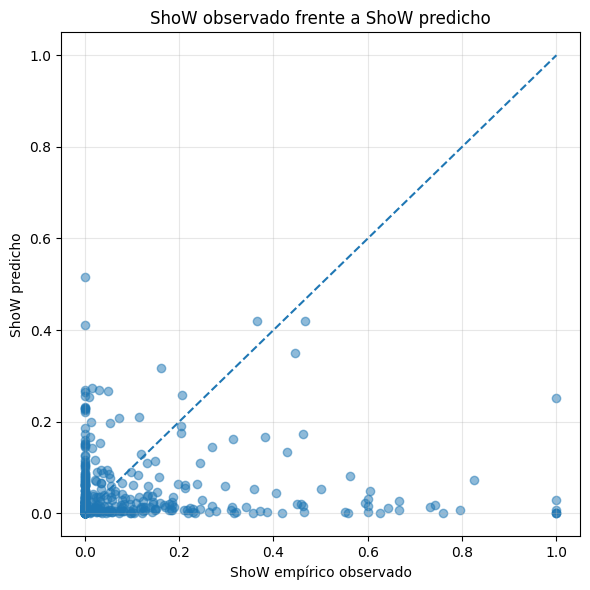

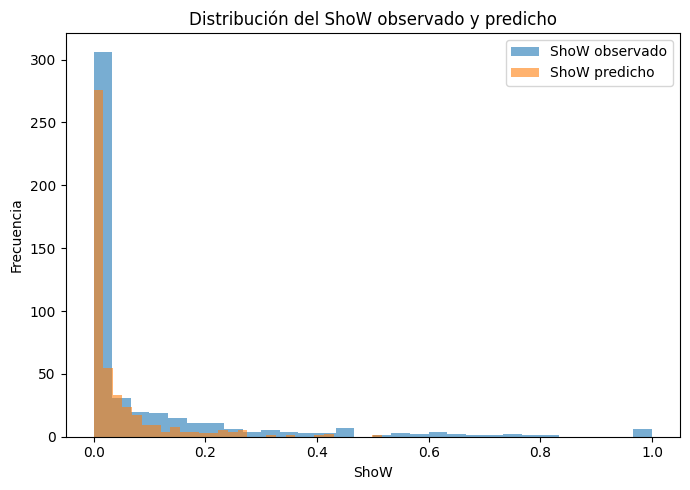

ShoW observado


count    469.000000
mean       0.089006
std        0.183407
min        0.000000
25%        0.000000
50%        0.000000
75%        0.095285
max        1.000000
Name: sow_empirical, dtype: float64

ShoW predicho


count    469.000000
mean       0.041390
std        0.070276
min        0.000027
25%        0.004488
50%        0.013659
75%        0.042513
max        0.515914
Name: sow_predicted, dtype: float64

In [22]:

########################################################################################
# Evaluación final en el conjunto de prueba
########################################################################################

y_pred_test = best_model_xgb_show.predict(
    X_test_f
)

if not (
    len(test_response_ids)
    == len(y_test)
    == len(y_pred_test)
):
    raise ValueError(
        "Los identificadores, los valores observados y "
        "las predicciones no tienen la misma longitud."
    )

if not np.all(
    (y_pred_test >= 0)
    & (y_pred_test <= 1)
):
    raise ValueError(
        "El modelo produjo predicciones fuera de [0, 1]."
    )

resultados_xgb_show = pd.DataFrame(
    {
        "response_id": test_response_ids.to_numpy(),
        "sow_empirical": y_test.to_numpy(),
        "sow_predicted": y_pred_test,
    }
)

resultados_xgb_show["absolute_error"] = (
    resultados_xgb_show["sow_empirical"]
    - resultados_xgb_show["sow_predicted"]
).abs()

mae_test = mean_absolute_error(
    y_test,
    y_pred_test,
)

mse_test = mean_squared_error(
    y_test,
    y_pred_test,
)

rmse_test = np.sqrt(
    mse_test
)

r2_test = r2_score(
    y_test,
    y_pred_test,
)

metricas_xgb_show = pd.DataFrame(
    {
        "metric": [
            "n_test",
            "MAE",
            "MSE",
            "RMSE",
            "R2",
            "prediction_min",
            "prediction_max",
        ],
        "value": [
            len(y_test),
            mae_test,
            mse_test,
            rmse_test,
            r2_test,
            float(y_pred_test.min()),
            float(y_pred_test.max()),
        ],
    }
)

display(metricas_xgb_show)

resultados_xgb_show.to_csv(
    ROOT / "xgboost_show_test_predictions.csv",
    index=False,
)

metricas_xgb_show.to_csv(
    ROOT / "xgboost_show_test_metrics.csv",
    index=False,
)

########################################################################################
# Gráficos de evaluación
########################################################################################

plt.figure(figsize=(6, 6))

plt.scatter(
    resultados_xgb_show["sow_empirical"],
    resultados_xgb_show["sow_predicted"],
    alpha=0.5,
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

plt.xlabel("ShoW empírico observado")
plt.ylabel("ShoW predicho")
plt.title("ShoW observado frente a ShoW predicho")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.hist(
    resultados_xgb_show["sow_empirical"],
    bins=30,
    alpha=0.6,
    label="ShoW observado",
)

plt.hist(
    resultados_xgb_show["sow_predicted"],
    bins=30,
    alpha=0.6,
    label="ShoW predicho",
)

plt.xlabel("ShoW")
plt.ylabel("Frecuencia")
plt.title("Distribución del ShoW observado y predicho")
plt.legend()
plt.tight_layout()
plt.show()

print("ShoW observado")
display(
    resultados_xgb_show["sow_empirical"]
    .describe()
)

print("ShoW predicho")
display(
    resultados_xgb_show["sow_predicted"]
    .describe()
)


## Celda 13. Importancia de variables

,feature,gain
0,Q-substance-use-marijuana_Prefer not to say,0.440893
1,Q-demos-gender_Other,0.232379
2,Q-substance-use-marijuana_I stopped in the rec...,0.194541
3,race_other,0.067117
4,dollar_avg_12m,0.026997
5,Q-substance-use-alcohol_Yes,0.026164
6,Q-demos-gender_Female,0.024805
7,frequency,0.023961
8,race_american_indian_native_american_or_alaska...,0.022175
9,recency_days,0.021398


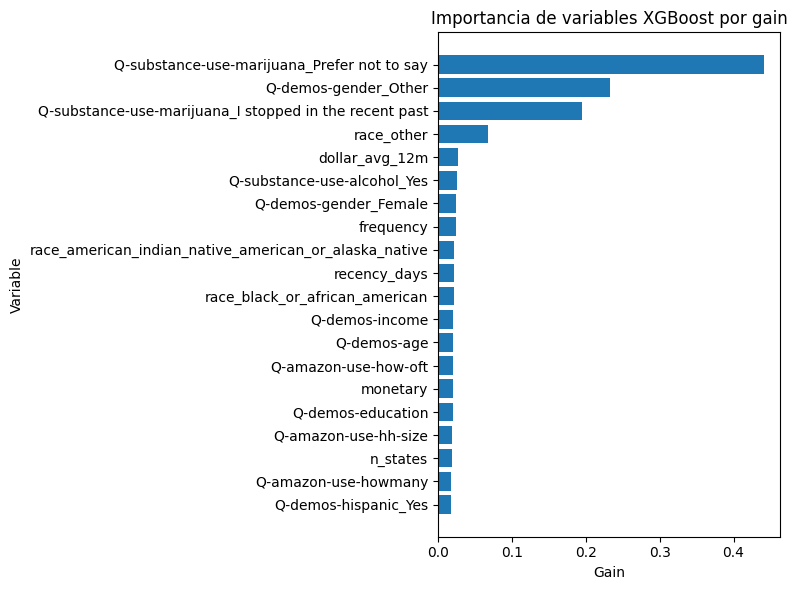

In [23]:

########################################################################################
# Importancia de variables del modelo optimizado
########################################################################################

preprocessor_fit = (
    best_model_xgb_show
    .named_steps["preprocessor"]
)

xgb_model = (
    best_model_xgb_show
    .named_steps["xgb"]
)

feature_names = (
    list(numeric_cols)
    + list(impute_cols)
    + list(cat_cols)
)

X_train_prep = preprocessor_fit.transform(
    X_train
)

if X_train_prep.shape[1] != len(feature_names):
    raise ValueError(
        "El número de columnas transformadas no coincide "
        "con los nombres reconstruidos."
    )

booster = xgb_model.get_booster()

importance_gain = booster.get_score(
    importance_type="gain"
)

importance_weight = booster.get_score(
    importance_type="weight"
)

def importance_to_dataframe(
    importance_dict: dict,
    value_name: str,
) -> pd.DataFrame:

    rows = []

    for key, value in importance_dict.items():
        feature_index = int(
            key.replace("f", "")
        )

        if feature_index >= len(feature_names):
            continue

        rows.append(
            {
                "feature": feature_names[feature_index],
                value_name: value,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values(
            value_name,
            ascending=False,
        )
        .reset_index(drop=True)
    )


importance_gain_df = importance_to_dataframe(
    importance_gain,
    "gain",
)

importance_weight_df = importance_to_dataframe(
    importance_weight,
    "weight",
)

importance_gain_df.to_csv(
    ROOT / "xgboost_show_feature_importance_gain.csv",
    index=False,
)

importance_weight_df.to_csv(
    ROOT / "xgboost_show_feature_importance_weight.csv",
    index=False,
)

display(
    importance_gain_df.head(30)
)

top20 = (
    importance_gain_df
    .head(20)
    .sort_values("gain")
)

plt.figure(figsize=(8, 6))

plt.barh(
    top20["feature"],
    top20["gain"],
)

plt.xlabel("Gain")
plt.ylabel("Variable")
plt.title("Importancia de variables XGBoost por gain")
plt.tight_layout()
plt.show()


## Interpretación y comparación

Las métricas obtenidas corresponden exclusivamente al conjunto de prueba. La comparación con Pogit solo debe realizarse cuando ambos modelos se evalúen sobre los mismos clientes, en el mismo orden y utilizando una única construcción del ShoW empírico.

No debe utilizarse el conjunto de prueba para seleccionar el número de variables. La importancia por `gain` se conserva únicamente como herramienta interpretativa.
